In [ ]:
!pip install alphagenome tqdm pandas matplotlib

DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/tensorflow_addons-0.23.0-py3.11-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/typeguard-2.13.3-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/protein_bert-1.0.1-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.

In [4]:
import re
import time
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from alphagenome.data import genome
from alphagenome.models import dna_client, variant_scorers


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

## DATASET ANALYSIS

In [5]:
import pandas as pd
from pathlib import Path

# Put your two VEP .txt files here
files = [
    "DATA1.txt",
    "DATA2.txt",
]

# If running inside this ChatGPT sandbox, use:
# files = ["/mnt/data/DATA1.txt", "/mnt/data/DATA2.txt"]


def find_header_line(path):
    """Find the VEP header line starting with #Uploaded_variation."""
    with open(path, "r") as f:
        for i, line in enumerate(f):
            if line.startswith("#Uploaded_variation") or line.startswith("Uploaded_variation"):
                return i
    raise ValueError(f"No VEP header found in {path}")


def parse_extra_field(extra):
    """Parse VEP compact Extra column: KEY=VALUE;KEY=VALUE."""
    d = {}
    if pd.isna(extra):
        return d

    for item in str(extra).split(";"):
        if "=" in item:
            key, value = item.split("=", 1)
            d[key] = value

    return d


def read_vep_file(path):
    """Read either full VEP table or compact VEP table with Extra column."""
    path = Path(path)
    header_line = find_header_line(path)

    df = pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        keep_default_na=False,
        skiprows=header_line,
    )

    # Remove leading # from header
    df.columns = [c.lstrip("#") for c in df.columns]

    # If compact VEP format, recover useful fields from Extra
    if "Extra" in df.columns:
        extra_dicts = df["Extra"].apply(parse_extra_field)

        for key in [
            "IMPACT",
            "SYMBOL",
            "BIOTYPE",
            "EXON",
            "INTRON",
            "REF_ALLELE",
            "UPLOADED_ALLELE",
            "STRAND",
            "MANE",
            "MANE_SELECT",
            "APPRIS",
            "SIFT",
            "PolyPhen",
            "CLIN_SIG",
        ]:
            if key not in df.columns:
                df[key] = extra_dicts.apply(lambda d: d.get(key, "-"))

    # Make sure key columns exist
    required_cols = [
        "Uploaded_variation",
        "Location",
        "Allele",
        "Consequence",
        "SYMBOL",
        "Gene",
        "Feature",
        "BIOTYPE",
        "IMPACT",
        "MANE",
        "MANE_SELECT",
        "REF_ALLELE",
        "UPLOADED_ALLELE",
    ]

    for col in required_cols:
        if col not in df.columns:
            df[col] = "-"

    df["file"] = path.name
    return df


# Read all files
dfs = [read_vep_file(f) for f in files]
vep = pd.concat(dfs, ignore_index=True)

print("Total annotation rows:", len(vep))
display(vep.head())

Total annotation rows: 13978


,Uploaded_variation,Location,Allele,Consequence,IMPACT,SYMBOL,Gene,Feature_type,Feature,BIOTYPE,...,SOMATIC,PHENO,PUBMED,MOTIF_NAME,MOTIF_POS,HIGH_INF_POS,MOTIF_SCORE_CHANGE,TRANSCRIPTION_FACTORS,file,Extra
0,rs80357258,17:43045712-43045712,C,missense_variant,MODERATE,BRCA1,ENSG00000012048,Transcript,ENST00000352993.8,protein_coding,...,-,"1,1",20516115,-,-,-,-,-,DATA1.txt,NaN
1,rs80357258,17:43045712-43045712,C,missense_variant,MODERATE,BRCA1,ENSG00000012048,Transcript,ENST00000357654.9,protein_coding,...,-,"1,1",20516115,-,-,-,-,-,DATA1.txt,NaN
2,rs80357258,17:43045712-43045712,C,"3_prime_UTR_variant,NMD_transcript_variant",MODIFIER,BRCA1,ENSG00000012048,Transcript,ENST00000461221.5,nonsense_mediated_decay,...,-,"1,1",20516115,-,-,-,-,-,DATA1.txt,NaN
3,rs80357258,17:43045712-43045712,C,missense_variant,MODERATE,BRCA1,ENSG00000012048,Transcript,ENST00000461574.3,protein_coding,...,-,"1,1",20516115,-,-,-,-,-,DATA1.txt,NaN
4,rs80357258,17:43045712-43045712,C,3_prime_UTR_variant,MODIFIER,BRCA1,ENSG00000012048,Transcript,ENST00000468300.6,protein_coding,...,-,"1,1",20516115,-,-,-,-,-,DATA1.txt,NaN


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

files = [
    "DATA1.txt",
    "DATA2.txt",
]

# If running in ChatGPT sandbox, use:
# files = ["/mnt/data/DATA1.txt", "/mnt/data/DATA2.txt"]


def parse_extra(extra):
    """Parse VEP Extra field: KEY=VALUE;KEY=VALUE."""
    d = {}

    if pd.isna(extra):
        return d

    for item in str(extra).split(";"):
        if "=" in item:
            key, value = item.split("=", 1)
            d[key] = value

    return d


def read_vep(path):
    """Read full VEP or compact VEP file."""
    path = Path(path)

    df = pd.read_csv(
        path,
        sep="\t",
        dtype=str,
        keep_default_na=False
    )

    df.columns = [c.lstrip("#") for c in df.columns]

    # DATA2-style compact VEP output:
    # SYMBOL and BIOTYPE are inside the Extra column
    if "Extra" in df.columns:
        extra = df["Extra"].apply(parse_extra)

        if "SYMBOL" not in df.columns:
            df["SYMBOL"] = extra.apply(lambda d: d.get("SYMBOL", "-"))

        if "BIOTYPE" not in df.columns:
            df["BIOTYPE"] = extra.apply(lambda d: d.get("BIOTYPE", "-"))

    # Safety fallback
    if "SYMBOL" not in df.columns:
        df["SYMBOL"] = "-"

    if "BIOTYPE" not in df.columns:
        df["BIOTYPE"] = "-"

    df["file"] = path.name

    return df


# Read both files
dfs = [read_vep(f) for f in files]
vep = pd.concat(dfs, ignore_index=True)

# Count SYMBOL rows per file
symbol_counts = (
    vep.groupby(["file", "SYMBOL"])
    .size()
    .reset_index(name="count")
)

display(symbol_counts)

# Pivot for plotting
plot_df = symbol_counts.pivot(
    index="SYMBOL",
    columns="file",
    values="count"
).fillna(0)

plot_df = plot_df.sort_values(plot_df.columns[0], ascending=False)

# Plot
ax = plot_df.plot(
    kind="bar",
    figsize=(8, 5),
    edgecolor="black"
)

ax.set_title("SYMBOL counts in DATA1.txt vs DATA2.txt")
ax.set_xlabel("SYMBOL")
ax.set_ylabel("Number of VEP annotation rows")
ax.legend(title="File")

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Check whether SYMBOL counts are identical
print("Are SYMBOL counts identical between files?")
print(plot_df.iloc[:, 0].equals(plot_df.iloc[:, 1]))

print("\nColumn counts:")
for df in dfs:
    print(df["file"].iloc[0], ":", df.shape[1], "columns,", df.shape[0], "rows")


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.2.6 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/ipykernel_launcher.py", line 17, in <module>
    app.launch_new_instance()
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/Users/marcamil/anaconda3/lib/python3.11/site-packages/ipykernel/kernelapp.py", line 736, in start
    self.io_loop.start()
  File "/Us

AttributeError: _ARRAY_API not found

ImportError: numpy.core.multiarray failed to import

In [4]:
!pip install "numpy<2" --force-reinstall
!pip install matplotlib pandas --upgrade --force-reinstall

DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/tensorflow_addons-0.23.0-py3.11-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/typeguard-2.13.3-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/protein_bert-1.0.1-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.

In [7]:
!pip install matplotlib pandas --upgrade --force-reinstall


DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/tensorflow_addons-0.23.0-py3.11-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/typeguard-2.13.3-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/protein_bert-1.0.1-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.

In [8]:
import sys
!{sys.executable} -m pip install --force-reinstall "numpy==1.26.4" "matplotlib==3.8.4" "pandas==2.2.2"

DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/tensorflow_addons-0.23.0-py3.11-macosx-11.1-arm64.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/typeguard-2.13.3-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.11/site-packages/protein_bert-1.0.1-py3.11.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /Users/marcamil/anaconda3/lib/python3.

In [1]:
import numpy
import matplotlib
import pandas

print(numpy.__version__)
print(matplotlib.__version__)
print(pandas.__version__)

1.26.4
3.8.4
2.2.2


Total pathogenic rows loaded: 4290
Rows after BRCA1 protein_coding filter: 742
Rows after removing missing scores: 742
Saved filtered CSV: BRCA1_pathogenic_only_filtered_scores.csv


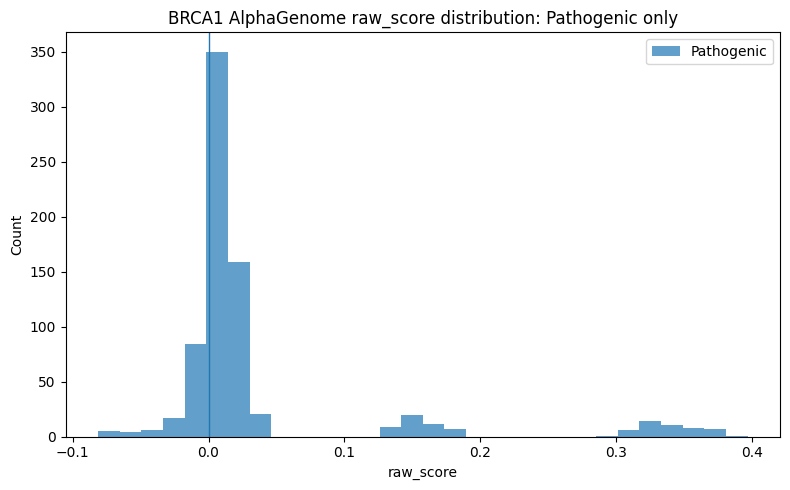

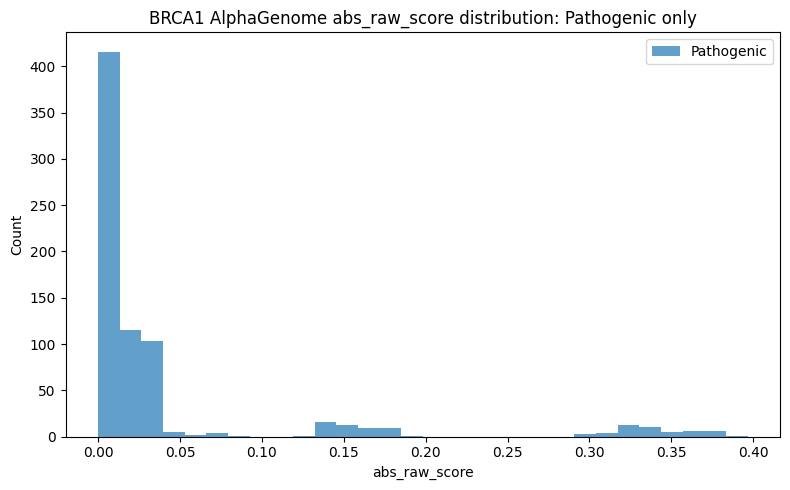

,raw_score,abs_raw_score
count,742.000000,742.000000
mean,0.038169,0.042916
std,0.088824,0.086626
min,-0.081229,0.000000
25%,0.001401,0.003628
50%,0.006671,0.009749
75%,0.026539,0.027702
max,0.396575,0.396575


In [2]:
# ============================================================
# AlphaGenome scores: Pathogenic only
# Filter: gene_name = BRCA1, gene_type = protein_coding
# Plot: raw_score and abs_raw_score distributions
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

# ----------------------------
# 1. CSV file path
# ----------------------------
PATHOGENIC_CSV = "DOGMA_RNAseq_UBERON_0000310_all_scores-2.csv"

# ----------------------------
# 2. Load pathogenic CSV only
# ----------------------------
df = pd.read_csv(PATHOGENIC_CSV)
df["clinvar_group"] = "pathogenic"

print("Total pathogenic rows loaded:", len(df))

# ----------------------------
# 3. Filter for BRCA1 protein-coding rows
# ----------------------------
filtered_df = df[
    (df["gene_name"].astype(str) == "BRCA1") &
    (df["gene_type"].astype(str) == "protein_coding")
].copy()

print("Rows after BRCA1 protein_coding filter:", len(filtered_df))

# ----------------------------
# 4. Make score columns numeric
# ----------------------------
filtered_df["raw_score"] = pd.to_numeric(
    filtered_df["raw_score"],
    errors="coerce"
)

if "abs_raw_score" in filtered_df.columns:
    filtered_df["abs_raw_score"] = pd.to_numeric(
        filtered_df["abs_raw_score"],
        errors="coerce"
    )
else:
    filtered_df["abs_raw_score"] = filtered_df["raw_score"].abs()

filtered_df = filtered_df.dropna(subset=["raw_score", "abs_raw_score"])

print("Rows after removing missing scores:", len(filtered_df))

# ----------------------------
# 5. Save filtered pathogenic CSV
# ----------------------------
output_csv = "BRCA1_pathogenic_only_filtered_scores.csv"
filtered_df.to_csv(output_csv, index=False)

print("Saved filtered CSV:", output_csv)

# ----------------------------
# 6. Plot pathogenic raw_score distribution
# ----------------------------
pathogenic_scores = filtered_df["raw_score"]

plt.figure(figsize=(8, 5))

plt.hist(
    pathogenic_scores,
    bins=30,
    alpha=0.7,
    label="Pathogenic"
)

plt.axvline(0, linewidth=1)

plt.xlabel("raw_score")
plt.ylabel("Count")
plt.title("BRCA1 AlphaGenome raw_score distribution: Pathogenic only")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 7. Plot pathogenic abs_raw_score distribution
# ----------------------------
pathogenic_abs_scores = filtered_df["abs_raw_score"]

plt.figure(figsize=(8, 5))

plt.hist(
    pathogenic_abs_scores,
    bins=30,
    alpha=0.7,
    label="Pathogenic"
)

plt.xlabel("abs_raw_score")
plt.ylabel("Count")
plt.title("BRCA1 AlphaGenome abs_raw_score distribution: Pathogenic only")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 8. Summary statistics
# ----------------------------
summary = filtered_df[["raw_score", "abs_raw_score"]].describe()

display(summary)

In [9]:
import pandas as pd

df = pd.read_csv("DOGMA_RNAseq_UBERON_0000310_all_scores-2.csv")
print(df.columns)
# Show all unique gene_type values
print(df["gene_type"].dropna().unique())

Index(['variant_id', 'scored_interval', 'gene_id', 'gene_name', 'gene_type',
       'gene_strand', 'junction_Start', 'junction_End', 'output_type',
       'variant_scorer', 'track_name', 'track_strand', 'Assay title',
       'ontology_curie', 'biosample_name', 'biosample_type',
       'biosample_life_stage', 'data_source', 'endedness',
       'genetically_modified', 'transcription_factor', 'histone_mark',
       'gtex_tissue', 'raw_score', 'quantile_score',
       'input_uploaded_variation', 'input_variant_id', 'position_mutation',
       'input_chromosome', 'input_position', 'input_ref', 'input_alt',
       'vep_SYMBOL', 'vep_Gene', 'vep_Feature', 'vep_Consequence',
       'vep_IMPACT', 'vep_CLIN_SIG', 'vep_Existing_variation', 'vep_SIFT',
       'vep_PolyPhen', 'vep_STRAND', 'abs_raw_score', 'abs_quantile_score'],
      dtype='object')
['protein_coding' 'lncRNA' 'processed_pseudogene' 'unprocessed_pseudogene'
 'transcribed_processed_pseudogene' 'transcribed_unprocessed_pseudogene']


Total pathogenic rows loaded: 4290
Rows after BRCA1 protein_coding/lncRNA filter: 742
gene_type
protein_coding    742
Name: count, dtype: int64
Rows after removing missing scores: 742
gene_type
protein_coding    742
Name: count, dtype: int64
Saved filtered CSV: BRCA1_pathogenic_protein_coding_lncRNA_filtered_scores.csv


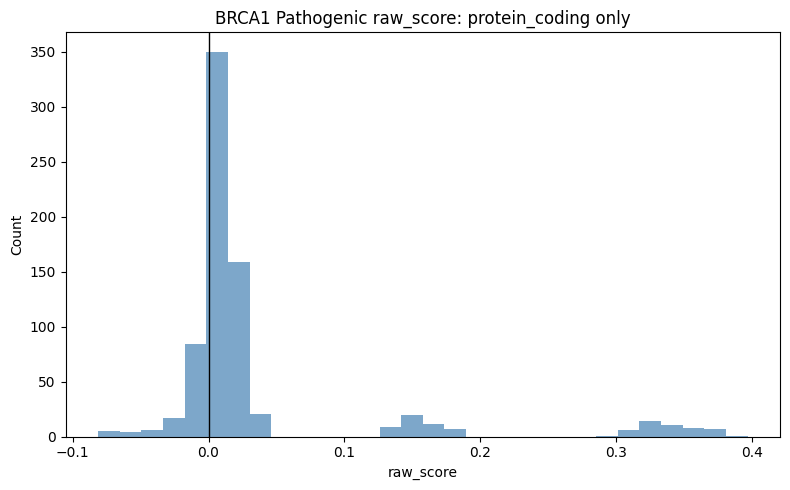

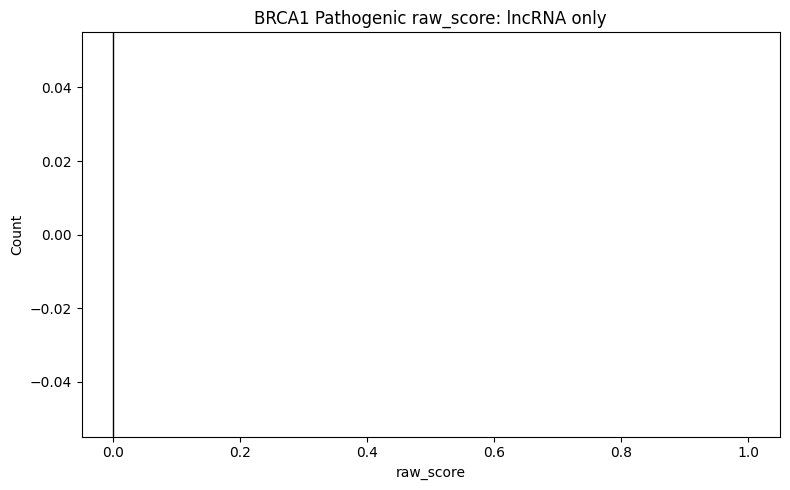

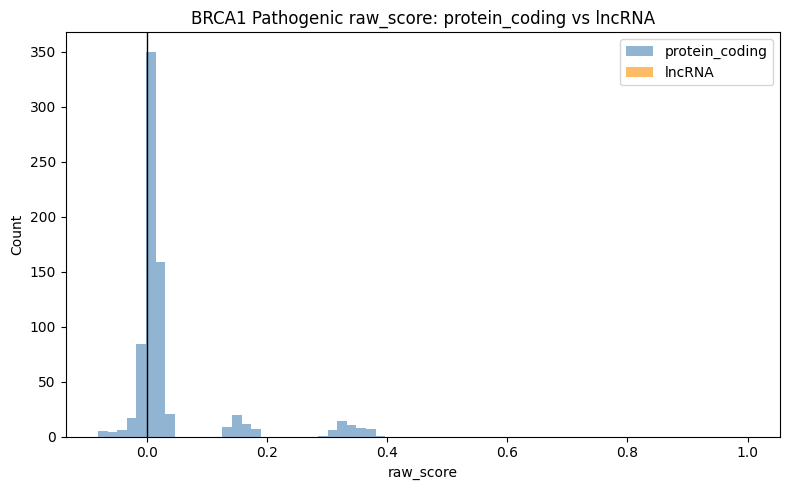

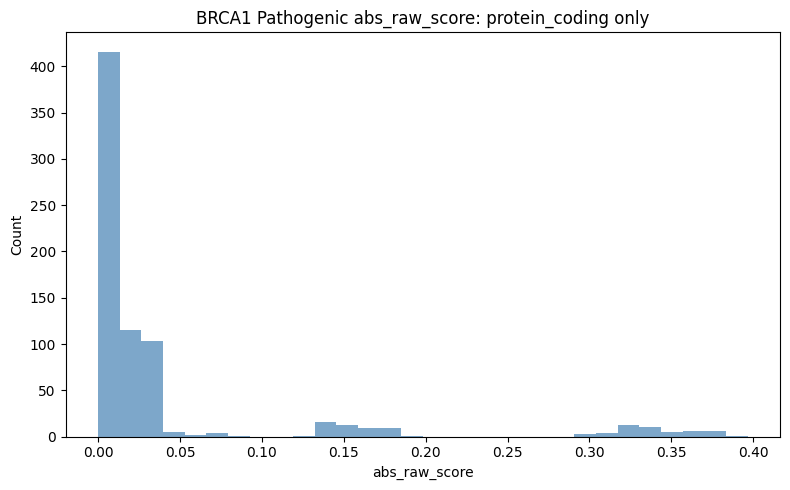

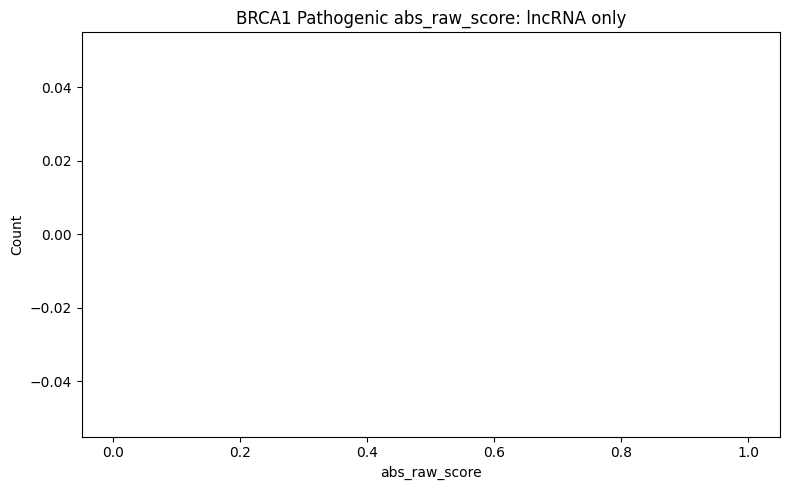

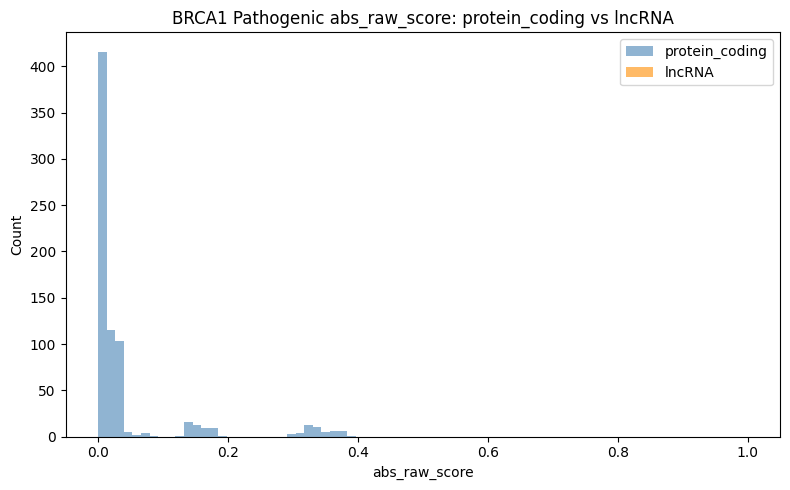

raw_score                                                    \
                   count      mean       std       min       25%       50%   
gene_type                                                                    
protein_coding     742.0  0.038169  0.088824 -0.081229  0.001401  0.006671   

                                   abs_raw_score                           \
                     75%       max         count      mean       std  min   
gene_type                                                                   
protein_coding  0.026539  0.396575         742.0  0.042916  0.086626  0.0   

                                                        
                     25%       50%       75%       max  
gene_type                                               
protein_coding  0.003628  0.009749  0.027702  0.396575

In [7]:
# ============================================================
# AlphaGenome scores: Pathogenic only
# Filter: gene_name = BRCA1
# Compare gene_type = protein_coding and lncRNA
# Plot separately and together
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

PATHOGENIC_CSV = "DOGMA_RNAseq_UBERON_0000310_all_scores-2.csv"

# ----------------------------
# 1. Load pathogenic CSV only
# ----------------------------
df = pd.read_csv(PATHOGENIC_CSV)
df["clinvar_group"] = "pathogenic"

print("Total pathogenic rows loaded:", len(df))

# ----------------------------
# 2. Filter BRCA1 and selected gene types
# ----------------------------
filtered_df = df[
    (df["gene_name"].astype(str) == "BRCA1") &
    (df["gene_type"].astype(str).isin(["protein_coding", "lncRNA"]))
].copy()

print("Rows after BRCA1 protein_coding/lncRNA filter:", len(filtered_df))
print(filtered_df["gene_type"].value_counts())

# ----------------------------
# 3. Make score columns numeric
# ----------------------------
filtered_df["raw_score"] = pd.to_numeric(
    filtered_df["raw_score"],
    errors="coerce"
)

if "abs_raw_score" in filtered_df.columns:
    filtered_df["abs_raw_score"] = pd.to_numeric(
        filtered_df["abs_raw_score"],
        errors="coerce"
    )
else:
    filtered_df["abs_raw_score"] = filtered_df["raw_score"].abs()

filtered_df = filtered_df.dropna(subset=["raw_score", "abs_raw_score"])

print("Rows after removing missing scores:", len(filtered_df))
print(filtered_df["gene_type"].value_counts())

# ----------------------------
# 4. Save filtered CSV
# ----------------------------
output_csv = "BRCA1_pathogenic_protein_coding_lncRNA_filtered_scores.csv"
filtered_df.to_csv(output_csv, index=False)

print("Saved filtered CSV:", output_csv)

# ----------------------------
# 5. Split by gene_type
# ----------------------------
protein_df = filtered_df[filtered_df["gene_type"] == "protein_coding"]
lncrna_df = filtered_df[filtered_df["gene_type"] == "lncRNA"]

# ============================================================
# Separate plots: raw_score
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(protein_df["raw_score"], bins=30, alpha=0.7, color="steelblue")
plt.axvline(0, linewidth=1, color="black")
plt.xlabel("raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic raw_score: protein_coding only")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(lncrna_df["raw_score"], bins=30, alpha=0.7, color="darkorange")
plt.axvline(0, linewidth=1, color="black")
plt.xlabel("raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic raw_score: lncRNA only")
plt.tight_layout()
plt.show()

# ============================================================
# Together plot: raw_score
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(
    protein_df["raw_score"],
    bins=30,
    alpha=0.6,
    color="steelblue",
    label="protein_coding"
)
plt.hist(
    lncrna_df["raw_score"],
    bins=30,
    alpha=0.6,
    color="darkorange",
    label="lncRNA"
)
plt.axvline(0, linewidth=1, color="black")
plt.xlabel("raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic raw_score: protein_coding vs lncRNA")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# Separate plots: abs_raw_score
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(protein_df["abs_raw_score"], bins=30, alpha=0.7, color="steelblue")
plt.xlabel("abs_raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic abs_raw_score: protein_coding only")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.hist(lncrna_df["abs_raw_score"], bins=30, alpha=0.7, color="darkorange")
plt.xlabel("abs_raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic abs_raw_score: lncRNA only")
plt.tight_layout()
plt.show()

# ============================================================
# Together plot: abs_raw_score
# ============================================================

plt.figure(figsize=(8, 5))
plt.hist(
    protein_df["abs_raw_score"],
    bins=30,
    alpha=0.6,
    color="steelblue",
    label="protein_coding"
)
plt.hist(
    lncrna_df["abs_raw_score"],
    bins=30,
    alpha=0.6,
    color="darkorange",
    label="lncRNA"
)
plt.xlabel("abs_raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic abs_raw_score: protein_coding vs lncRNA")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# Summary statistics
# ----------------------------
summary = (
    filtered_df
    .groupby("gene_type")[["raw_score", "abs_raw_score"]]
    .describe()
)

display(summary)

Total rows loaded: 4290

All gene_type values in full CSV:
gene_type
protein_coding                        2310
processed_pseudogene                   736
lncRNA                                 552
transcribed_unprocessed_pseudogene     276
unprocessed_pseudogene                 208
transcribed_processed_pseudogene       208
Name: count, dtype: int64

BRCA1 rows: 742

Gene_type values for BRCA1:
gene_type
protein_coding    742
Name: count, dtype: int64

Unique BRCA1 gene_name/gene_type combinations:
  gene_name       gene_type
0     BRCA1  protein_coding

Rows after BRCA1 protein_coding/lncRNA filter: 742
gene_type
protein_coding    742
Name: count, dtype: int64

Rows after removing missing scores: 742
gene_type
protein_coding    742
Name: count, dtype: int64

Saved filtered CSV: BRCA1_pathogenic_protein_coding_lncRNA_filtered_scores.csv

protein_coding rows: 742
lncRNA rows: 0


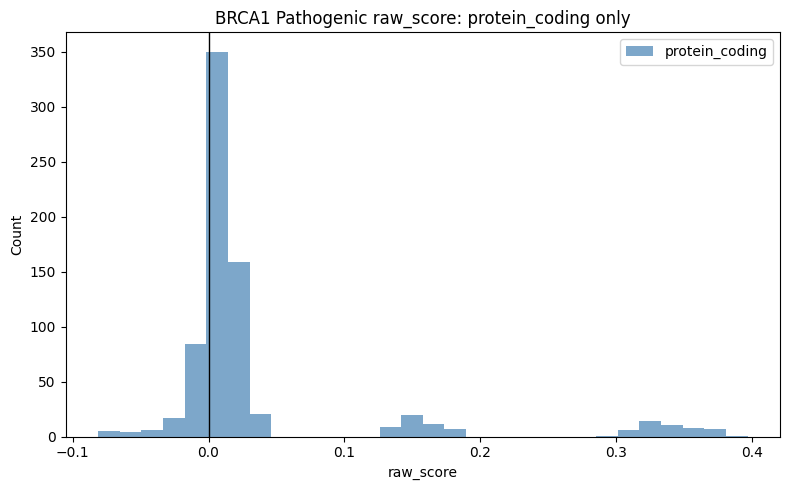

Skipping plot: no rows for lncRNA


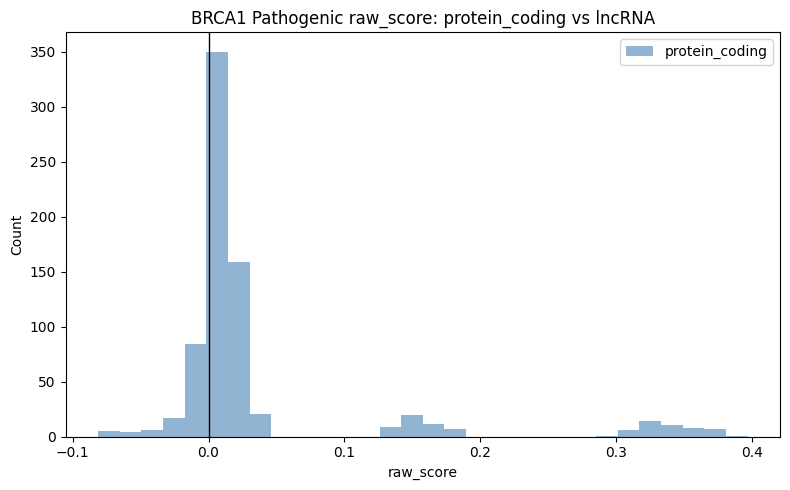

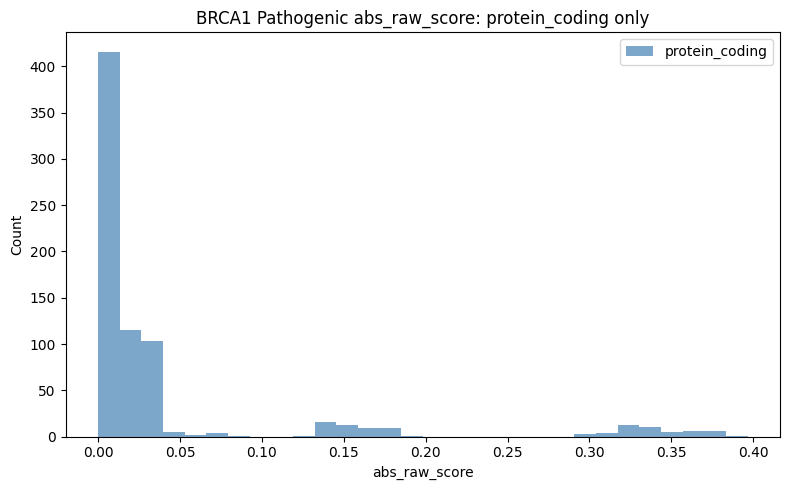

Skipping plot: no rows for lncRNA


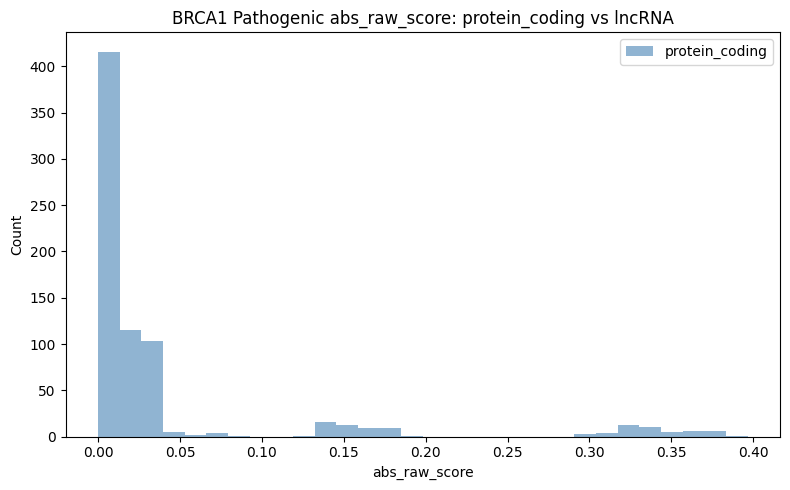

raw_score                                                    \
                   count      mean       std       min       25%       50%   
gene_type                                                                    
protein_coding     742.0  0.038169  0.088824 -0.081229  0.001401  0.006671   

                                   abs_raw_score                           \
                     75%       max         count      mean       std  min   
gene_type                                                                   
protein_coding  0.026539  0.396575         742.0  0.042916  0.086626  0.0   

                                                        
                     25%       50%       75%       max  
gene_type                                               
protein_coding  0.003628  0.009749  0.027702  0.396575

In [8]:
# ============================================================
# AlphaGenome scores: Pathogenic only
# Check BRCA1 gene_type values and plot available types
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

PATHOGENIC_CSV = "DOGMA_RNAseq_UBERON_0000310_all_scores-2.csv"

# ----------------------------
# 1. Load CSV
# ----------------------------
df = pd.read_csv(PATHOGENIC_CSV)
df["clinvar_group"] = "pathogenic"

# Clean text columns to remove hidden spaces
df["gene_name"] = df["gene_name"].astype(str).str.strip()
df["gene_type"] = df["gene_type"].astype(str).str.strip()

print("Total rows loaded:", len(df))

# ----------------------------
# 2. Check gene_type values in whole file
# ----------------------------
print("\nAll gene_type values in full CSV:")
print(df["gene_type"].value_counts(dropna=False))

# ----------------------------
# 3. Check gene_type values for BRCA1 only
# ----------------------------
brca1_df = df[df["gene_name"] == "BRCA1"].copy()

print("\nBRCA1 rows:", len(brca1_df))
print("\nGene_type values for BRCA1:")
print(brca1_df["gene_type"].value_counts(dropna=False))

print("\nUnique BRCA1 gene_name/gene_type combinations:")
print(brca1_df[["gene_name", "gene_type"]].drop_duplicates())

# ----------------------------
# 4. Filter BRCA1 for protein_coding and lncRNA
# ----------------------------
filtered_df = brca1_df[
    brca1_df["gene_type"].isin(["protein_coding", "lncRNA"])
].copy()

print("\nRows after BRCA1 protein_coding/lncRNA filter:", len(filtered_df))
print(filtered_df["gene_type"].value_counts(dropna=False))

# ----------------------------
# 5. Make score columns numeric
# ----------------------------
filtered_df["raw_score"] = pd.to_numeric(
    filtered_df["raw_score"],
    errors="coerce"
)

if "abs_raw_score" in filtered_df.columns:
    filtered_df["abs_raw_score"] = pd.to_numeric(
        filtered_df["abs_raw_score"],
        errors="coerce"
    )
else:
    filtered_df["abs_raw_score"] = filtered_df["raw_score"].abs()

filtered_df = filtered_df.dropna(subset=["raw_score", "abs_raw_score"])

print("\nRows after removing missing scores:", len(filtered_df))
print(filtered_df["gene_type"].value_counts(dropna=False))

# ----------------------------
# 6. Save filtered CSV
# ----------------------------
output_csv = "BRCA1_pathogenic_protein_coding_lncRNA_filtered_scores.csv"
filtered_df.to_csv(output_csv, index=False)

print("\nSaved filtered CSV:", output_csv)

# ----------------------------
# 7. Split gene types
# ----------------------------
protein_df = filtered_df[filtered_df["gene_type"] == "protein_coding"]
lncrna_df = filtered_df[filtered_df["gene_type"] == "lncRNA"]

print("\nprotein_coding rows:", len(protein_df))
print("lncRNA rows:", len(lncrna_df))

# ============================================================
# Plot function
# ============================================================

def plot_hist(data, score_col, title, color, label):
    if len(data) == 0:
        print(f"Skipping plot: no rows for {label}")
        return
    
    plt.figure(figsize=(8, 5))
    plt.hist(
        data[score_col],
        bins=30,
        alpha=0.7,
        color=color,
        label=label
    )
    
    if score_col == "raw_score":
        plt.axvline(0, linewidth=1, color="black")
    
    plt.xlabel(score_col)
    plt.ylabel("Count")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ============================================================
# 8. Separate plots: raw_score
# ============================================================

plot_hist(
    protein_df,
    "raw_score",
    "BRCA1 Pathogenic raw_score: protein_coding only",
    "steelblue",
    "protein_coding"
)

plot_hist(
    lncrna_df,
    "raw_score",
    "BRCA1 Pathogenic raw_score: lncRNA only",
    "darkorange",
    "lncRNA"
)

# ============================================================
# 9. Together plot: raw_score
# ============================================================

plt.figure(figsize=(8, 5))

if len(protein_df) > 0:
    plt.hist(
        protein_df["raw_score"],
        bins=30,
        alpha=0.6,
        color="steelblue",
        label="protein_coding"
    )

if len(lncrna_df) > 0:
    plt.hist(
        lncrna_df["raw_score"],
        bins=30,
        alpha=0.6,
        color="darkorange",
        label="lncRNA"
    )

plt.axvline(0, linewidth=1, color="black")
plt.xlabel("raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic raw_score: protein_coding vs lncRNA")
plt.legend()
plt.tight_layout()
plt.show()

# ============================================================
# 10. Separate plots: abs_raw_score
# ============================================================

plot_hist(
    protein_df,
    "abs_raw_score",
    "BRCA1 Pathogenic abs_raw_score: protein_coding only",
    "steelblue",
    "protein_coding"
)

plot_hist(
    lncrna_df,
    "abs_raw_score",
    "BRCA1 Pathogenic abs_raw_score: lncRNA only",
    "darkorange",
    "lncRNA"
)

# ============================================================
# 11. Together plot: abs_raw_score
# ============================================================

plt.figure(figsize=(8, 5))

if len(protein_df) > 0:
    plt.hist(
        protein_df["abs_raw_score"],
        bins=30,
        alpha=0.6,
        color="steelblue",
        label="protein_coding"
    )

if len(lncrna_df) > 0:
    plt.hist(
        lncrna_df["abs_raw_score"],
        bins=30,
        alpha=0.6,
        color="darkorange",
        label="lncRNA"
    )

plt.xlabel("abs_raw_score")
plt.ylabel("Count")
plt.title("BRCA1 Pathogenic abs_raw_score: protein_coding vs lncRNA")
plt.legend()
plt.tight_layout()
plt.show()

# ----------------------------
# 12. Summary statistics
# ----------------------------
summary = (
    filtered_df
    .groupby("gene_type")[["raw_score", "abs_raw_score"]]
    .describe()
)

display(summary)